In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Nel caso di clustering non è possibile utilizzare la GridSearch perchè la GridSearch prende in input il dataset delle feature X e quello del target y (facendo poi la cross validation), ma nel caso di clustering il target y non è presente, non è noto, quindi la GridSearch non può funzionare.
Quindi facciamo dei loop manuali per vedere quali sono i migliori k-means per categorizzare il dataset win
Fare un ciclo for sui parametri, salvare per ogni prova: parametri, n cluster, silhouette, percentuale noise, numerosità cluster. Controlla sempre se i cluster hanno senso operativo, senso nel contesto.

Carico il dataset

In [7]:
data=load_wine()
X=data.data
y=data.target

feature_names=data.feature_names

Data splitting

In [8]:
X_train, X_test, y_train, y_test=train_test_split(X,y,shuffle=True,stratify=y,test_size=0.2,random_state=42)

Scaling dei dati (importante per k-means perchè si basa sulle distanze)

In [11]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
#alleno il modello di default
kmeans_default=KMeans(random_state=42)
kmeans_default.fit(X_test_scaled)
y_train_pred_default=kmeans_default.predict(X_train_scaled)
silhouette_default=silhouette_score(X_train_scaled,y_train_pred_default)

c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Creo il secondo modello con il tunning sulla base di 3 parametri, n_cluster (k), init (metodo, di default è k-means++) e n_init

In [15]:
param_grid={"n_clusters":[2,3,4,5],"init":["k-means++","random"],"n_init":[10,20]}

best_kmeans=None
best_params=None
silhouette_best=-1 #peggiore, metrica per isolare quanto ogni singolo cluster è coeso all'interno e separato dagli altri cluster

for n_clusters in param_grid["n_clusters"]:
    for init in param_grid["init"]:
        for n_init in param_grid["n_init"]:
            kmeans=KMeans(init=init,n_clusters=n_clusters, n_init=n_init,random_state=42)
            kmeans.fit(X_train_scaled)
            score=silhouette_score(X_train_scaled,kmeans.labels_)
            if score>silhouette_best:
                silhouette_best=score
                best_params={"init":init,"n_init":n_init,"n_clusters":n_clusters}
                best_kmeans=kmeans


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: User

In [25]:
print(f"Migliori parametri:\n{best_params}")
print(f"Silhouette (default):\t{silhouette_default}")
print(f"Silhouette (best/tunned):\t{silhouette_best}")

Migliori parametri:
{'init': 'random', 'n_init': 10, 'n_clusters': 3}
Silhouette (default):	0.09921359541111949
Silhouette (best/tunned):	0.28802163614154114


per plottare il tutto porto a due livelli (2D)

In [35]:
pca=PCA(n_components=2)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

#riaddestro entrambi i modelli (default e best) sui dati pca per fare il plot
kmeans_default_pca=KMeans(n_clusters=kmeans_default.n_clusters,random_state=42)
kmeans_default_pca.fit(X_train_pca)
kmeans_best_pca=KMeans(**best_params,random_state=42)
kmeans_best_pca.fit(X_train_pca);


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [40]:
def plot_clusters(ax,X,labels,model, title):
   h = 0.02
   x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
   y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
   xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
   Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
   Z = Z.reshape(xx.shape)
   ax.contourf(xx, yy, Z, alpha=0.3)
   ax.scatter(X[:, 0], X[:, 1], c=labels, s=50, edgecolor='k')
   ax.set_title(title)
   ax.set_xlabel("PC 1")
   ax.set_label("PC 2")

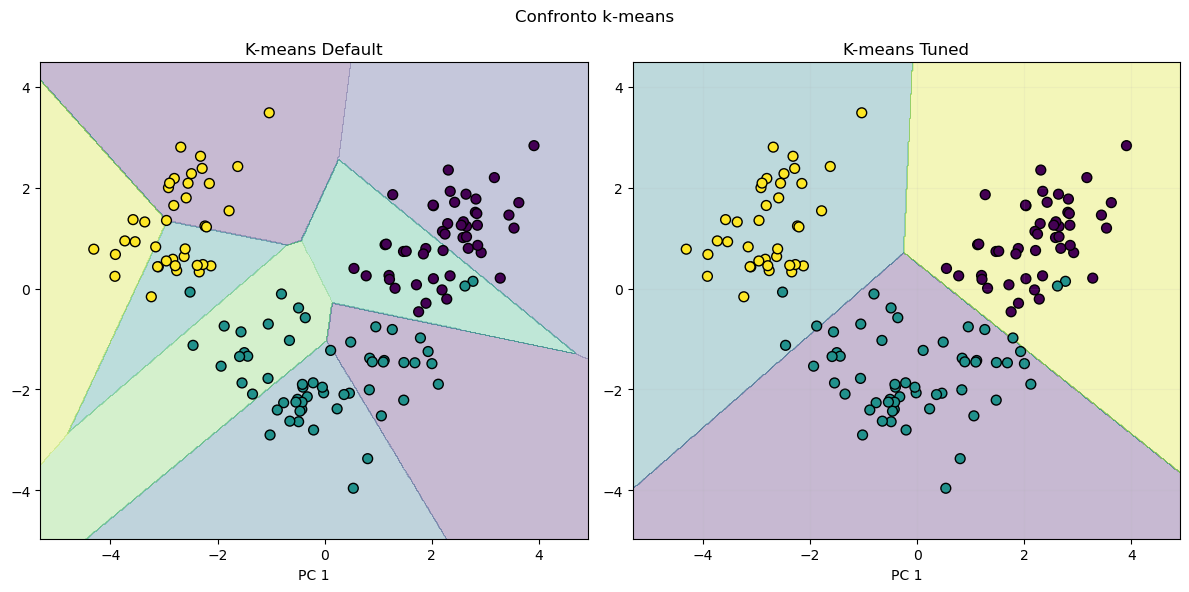

In [42]:
fig,axes=plt.subplots(1,2,figsize=(12,6))
plot_clusters(axes[0],X_train_pca,y_train,kmeans_default_pca,"K-means Default")
plot_clusters(axes[1],X_train_pca,y_train,kmeans_best_pca,"K-means Tuned")
plt.suptitle("Confronto k-means")
plt.tight_layout()
plt.grid(True,alpha=0.1)
plt.show()
